In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU

In [2]:
df = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2024-01-01",
    progress=False,
    auto_adjust=False
)

if df.empty:
    print("❌ Data not loaded")
else:
    print("✅ Data loaded successfully")
    print(df.head())

✅ Data loaded successfully
Price       Adj Close      Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                                        
2020-01-02  72.400520  75.087502  75.150002  73.797501  74.059998  135480400
2020-01-03  71.696655  74.357498  75.144997  74.125000  74.287498  146322800
2020-01-06  72.267921  74.949997  74.989998  73.187500  73.447502  118387200
2020-01-07  71.928062  74.597504  75.224998  74.370003  74.959999  108872000
2020-01-08  73.085106  75.797501  76.110001  74.290001  74.290001  132079200


In [3]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df = df.dropna()

print("Shape:", df.shape)

Shape: (1006, 5)


In [4]:
df['Next_Close'] = df['Close'].shift(-1)

df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)

df['MA5'] = df['Close'].rolling(5).mean()
df['MA10'] = df['Close'].rolling(10).mean()

df.dropna(inplace=True)

In [5]:
X = df[['Open','High','Low','Volume','Close_lag1','Close_lag2','MA5','MA10']]
y = df['Next_Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [7]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [8]:
def evaluate(name, y_true, y_pred):
    print("\n", name)
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

In [9]:
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)


 Linear Regression
MSE: 5.136457989883383
MAE: 1.6945819033571143
R2: 0.9550752965304966

 Random Forest
MSE: 80.2183862125655
MAE: 6.533635640403873
R2: 0.2983905990276726


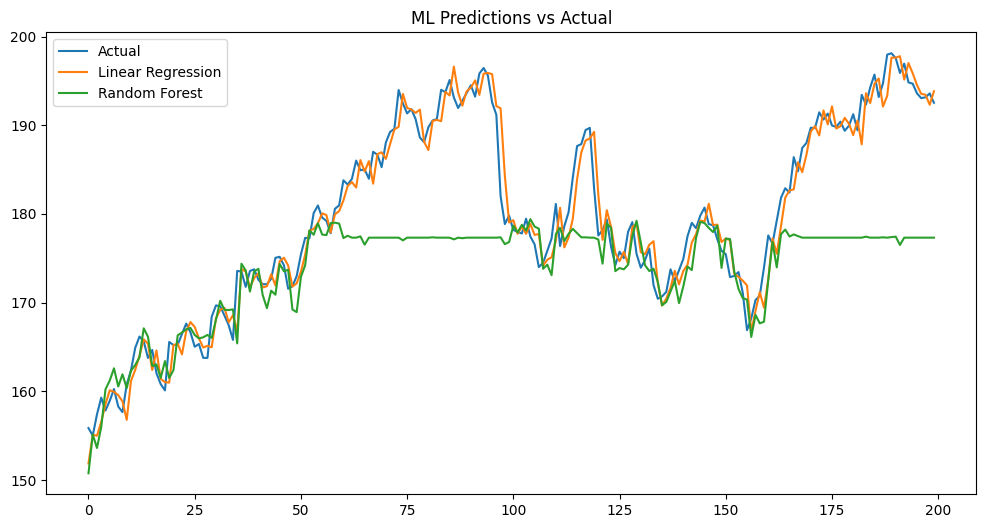

In [10]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(lr_pred, label="Linear Regression")
plt.plot(rf_pred, label="Random Forest")
plt.legend()
plt.title("ML Predictions vs Actual")
plt.show()

In [11]:
features = df[['Open','High','Low','Close','Volume']]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

seq_len = 30

X_lstm, y_lstm = [], []

for i in range(seq_len, len(scaled)):
    X_lstm.append(scaled[i-seq_len:i])
    y_lstm.append(scaled[i, 3])  # Close price

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

split = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

In [12]:
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(32),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, validation_split=0.1)

d:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0187 - val_loss: 0.0024
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0024 - val_loss: 0.0029
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0015 - val_loss: 0.0024
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0

In [13]:
lstm_pred = lstm.predict(X_test_lstm)

dummy = np.zeros((len(lstm_pred), 5))
dummy[:,3] = lstm_pred[:,0]

lstm_pred = scaler.inverse_transform(dummy)[:,3]

dummy2 = np.zeros((len(y_test_lstm), 5))
dummy2[:,3] = y_test_lstm

y_test_actual = scaler.inverse_transform(dummy2)[:,3]

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step


In [14]:
evaluate("LSTM", y_test_actual, lstm_pred)


 LSTM
MSE: 12.89443765181218
MAE: 2.8072713603368107
R2: 0.8756860152884838


In [15]:
gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    GRU(32),
    Dense(1)
])

gru.compile(optimizer='adam', loss='mse')
gru.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, validation_split=0.1)

d:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 0.0210 - val_loss: 0.0016
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0011 - val_loss: 8.5878e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 8.5151e-04 - val_loss: 7.7013e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 7.8192e-04 - val_loss: 6.2577e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 7.0527e-04 - val_loss: 5.8966e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.4002e-04 - val_loss: 5.8467e-04
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 6.5856e-04 - val_loss: 5.8027e-04
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.8435e-04 - val_loss: 7.4442e-04
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.9242e-04 - val_loss: 4.8368e-04
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.5822e-04 - val_loss: 5.0300e-04
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 5.4617e-04 - val_loss

In [16]:
gru_pred = gru.predict(X_test_lstm)

dummy = np.zeros((len(gru_pred), 5))
dummy[:,3] = gru_pred[:,0]

gru_pred = scaler.inverse_transform(dummy)[:,3]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


In [17]:
evaluate("GRU", y_test_actual, gru_pred)


 GRU
MSE: 5.49514869108547
MAE: 1.8030998014251582
R2: 0.947021820662718


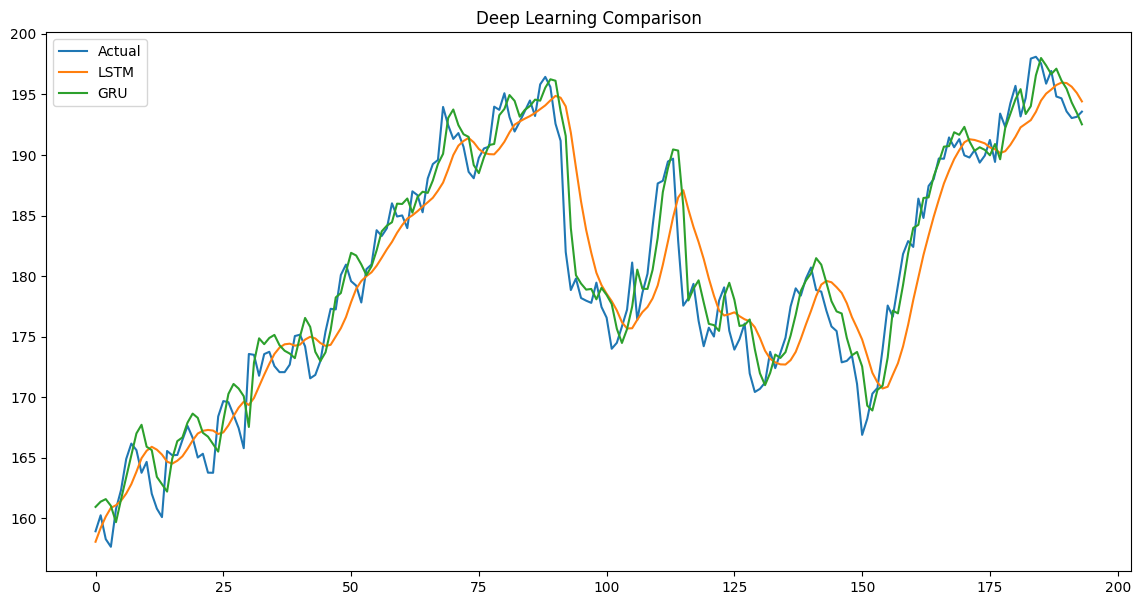

In [18]:
plt.figure(figsize=(14,7))
plt.plot(y_test_actual, label="Actual")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.title("Deep Learning Comparison")
plt.show()

In [19]:
def backtest(actual, pred, name):
    df_bt = pd.DataFrame({
        "Actual": actual,
        "Pred": pred
    })

    df_bt["Prev"] = df_bt["Actual"].shift(1)
    df_bt.dropna(inplace=True)

    df_bt["Signal"] = np.where(df_bt["Pred"] > df_bt["Prev"], 1, -1)

    df_bt["Return"] = df_bt["Actual"].pct_change()
    df_bt["Strategy"] = df_bt["Signal"].shift(1) * df_bt["Return"]

    df_bt.dropna(inplace=True)

    final = (1 + df_bt["Strategy"]).cumprod().iloc[-1]

    print(name, "Return:", final)

In [20]:
backtest(y_test.values, lr_pred, "LR")
backtest(y_test.values, rf_pred, "RF")
backtest(y_test_actual, lstm_pred, "LSTM")
backtest(y_test_actual, gru_pred, "GRU")

LR Return: 1.2209710488797416
RF Return: 0.9765564240399452
LSTM Return: 1.0000088384595887
GRU Return: 1.097370795747208


In [21]:
def backtest_metrics(actual, pred):
    df_bt = pd.DataFrame({
        "Actual": actual,
        "Pred": pred
    })

    df_bt["Prev"] = df_bt["Actual"].shift(1)
    df_bt.dropna(inplace=True)

    df_bt["Signal"] = np.where(df_bt["Pred"] > df_bt["Prev"], 1, -1)

    df_bt["Return"] = df_bt["Actual"].pct_change()
    df_bt["Strategy"] = df_bt["Signal"].shift(1) * df_bt["Return"]

    df_bt.dropna(inplace=True)

    total_return = (1 + df_bt["Strategy"]).cumprod().iloc[-1]

    sharpe = (df_bt["Strategy"].mean() / (df_bt["Strategy"].std() + 1e-9)) * np.sqrt(252)

    equity = (1 + df_bt["Strategy"]).cumprod()
    drawdown = (equity.cummax() - equity) / equity.cummax()
    max_drawdown = drawdown.max()

    score = (total_return * 0.5) + (sharpe * 0.3) - (max_drawdown * 0.2)

    return total_return, sharpe, max_drawdown, score

In [22]:
results = {}

results["Linear Regression"] = backtest_metrics(y_test.values, lr_pred)
results["Random Forest"] = backtest_metrics(y_test.values, rf_pred)
results["LSTM"] = backtest_metrics(y_test_actual, lstm_pred)
results["GRU"] = backtest_metrics(y_test_actual, gru_pred)

df_results = pd.DataFrame(results).T
df_results.columns = ["Return", "Sharpe", "Max Drawdown", "Score"]

df_results = df_results.sort_values("Score", ascending=False)

print("\nPROFESSIONAL MODEL LEADERBOARD\n")
print(df_results)


PROFESSIONAL MODEL LEADERBOARD

                     Return    Sharpe  Max Drawdown     Score
Linear Regression  1.220971  1.451697      0.189875  1.008020
GRU                1.097371  0.741243      0.228011  0.725456
LSTM               1.000009  0.093821      0.202036  0.487744
Random Forest      0.976556 -0.067866      0.212780  0.425362
